# GP-KAN with GPytorch

このnotebookでは、GPytorch/linear-operatorライブラリを使用してGP-KANの効率的な実装を行います。

## 目次
1. ライブラリのインポートと設定
2. シミュレーションデータでの検証
3. 実装結果のまとめ

In [1]:
# 設定
LR = 0.01
BATCH_SIZE = 64
NUM_EPOCHS = 1000
# ARCHITECTURE = [2, 1]
# ARCHITECTURE = [2, 2, 1]
ARCHITECTURE = [2, 4, 1]
NUM_INDUCING = 8

# カーネルだけ手動変更: 今後実装

## 1. ライブラリのインポートと設定

In [2]:
# 基本ライブラリのインポート
import time
import warnings
from typing import Optional, Tuple

import japanize_matplotlib  # 日本語フォント対応
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

warnings.filterwarnings("ignore")

# Linear Operator関連のインポート
from linear_operator.operators import (
    AddedDiagLinearOperator,
    DenseLinearOperator,
    DiagLinearOperator,
    LinearOperator,
    MatmulLinearOperator,
    RootLinearOperator,
    ZeroLinearOperator,
)
from linear_operator.utils.cholesky import psd_safe_cholesky

# 可視化設定
plt.style.use("default")

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Linear Operator successfully imported")

PyTorch version: 2.6.0
CUDA available: False
Linear Operator successfully imported


In [3]:
# GPytorch関連のインポート
import gpytorch
from gpytorch.distributions import MultivariateNormal
from gpytorch.kernels import RBFKernel, ScaleKernel
from gpytorch.likelihoods import GaussianLikelihood
from gpytorch.means import ConstantMean
from gpytorch.mlls import VariationalELBO
from gpytorch.variational import CholeskyVariationalDistribution, VariationalStrategy

print("GPytorch version:", gpytorch.__version__)
print("GPytorch successfully imported")

GPytorch version: 1.14
GPytorch successfully imported


## 2. シミュレーションデータでの検証

フーリエ級数を使ったシミュレーションデータでGP-KANの動作を確認します。

In [4]:
# 目標関数の定義: f₁(x) = x₁ + x₂ + c
# 各座標成分の和を出力とする線形関数

# 固定パラメータ
c = -10.0  # 定数項
reference_point = np.array([0.5, 0.3])  # 参考点（最適解は存在しない）


def target_function(x):
    """
    目標関数: f₁(x) = x₁ + x₂ + c
    Args:
        x: 入力ベクトル (N, 2) または (2,)
    Returns:
        関数値 (N,) または スカラー
    """
    x = np.array(x)
    if x.ndim == 1:
        x = x.reshape(1, -1)

    # x₁ + x₂ + c の計算
    result = x[:, 0] + x[:, 1] + c

    return result if len(result) > 1 else result[0]


# 動作確認
print("目標関数のテスト:")
print(f"定数項 c = {c}")
print(f"参考点 = {reference_point}")
print(f"f(参考点) = {target_function(reference_point):.6f} (= {reference_point[0]} + {reference_point[1]} + {c})")
print(f"f([0, 0]) = {target_function([0, 0]):.6f}")
print(f"f([1, 1]) = {target_function([1, 1]):.6f}")
print(f"f([2, 3]) = {target_function([2, 3]):.6f}")


目標関数のテスト:
定数項 c = -10.0
参考点 = [0.5 0.3]
f(参考点) = -9.200000 (= 0.5 + 0.3 + -10.0)
f([0, 0]) = -10.000000
f([1, 1]) = -8.000000
f([2, 3]) = -5.000000


In [5]:
# 初期設定: 必要なライブラリをインポートし、パスを設定
import os
import random
import sys
import time

sys.path.append("../../")
import gpytorch
import japanize_matplotlib
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import tqdm.notebook
from gpytorch.distributions import MultivariateNormal
from gpytorch.kernels import PolynomialKernel, RBFKernel, ScaleKernel
from gpytorch.likelihoods import GaussianLikelihood
from gpytorch.means import ConstantMean, LinearMean
from gpytorch.mlls import DeepApproximateMLL, VariationalELBO
from gpytorch.variational import CholeskyVariationalDistribution, VariationalStrategy
from torch.utils.data import DataLoader, TensorDataset


# 再現性のための乱数シード設定
def set_seed(seed=42):
    """完全な再現性のための乱数シード設定"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)


def worker_init_fn(worker_id):
    """DataLoaderワーカープロセス用の乱数シード設定"""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


set_seed(42)  # 全体の乱数シード設定
print("ライブラリのインポートと初期設定完了")

ライブラリのインポートと初期設定完了


In [6]:
# データセットの作成
num_samples = 1000
input_range = [-2, 2]  # 入力範囲

# 2次元入力点をランダムサンプリング
X = np.random.uniform(input_range[0], input_range[1], (num_samples, 2))

# 目標関数値を計算
y = target_function(X)

# PyTorchテンソルに変換
X_tensor = torch.FloatTensor(X)
y_tensor = torch.FloatTensor(y).reshape(-1, 1)

# データ分割（学習:検証:テスト = 7:1.5:1.5）
train_size = int(0.7 * num_samples)
val_size = int(0.15 * num_samples)
test_size = num_samples - train_size - val_size

X_train = X_tensor[:train_size]
y_train = y_tensor[:train_size]

X_val = X_tensor[train_size : train_size + val_size]
y_val = y_tensor[train_size : train_size + val_size]

X_test = X_tensor[train_size + val_size :]
y_test = y_tensor[train_size + val_size :]

# データセット作成
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

# データローダー作成
batch_size = BATCH_SIZE  # DeepGPでは少し大きめのバッチサイズを使用
generator = torch.Generator()
generator.manual_seed(42)

train_dataloader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    worker_init_fn=worker_init_fn,
    generator=generator,
)
val_dataloader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    worker_init_fn=worker_init_fn,
    generator=generator,
)
test_dataloader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    worker_init_fn=worker_init_fn,
    generator=generator,
)

print(f"データセット作成完了:")
print(f"  学習データ: {len(train_dataset)} samples")
print(f"  検証データ: {len(val_dataset)} samples")
print(f"  テストデータ: {len(test_dataset)} samples")
print(f"  入力次元: {X_train.shape[1]}")
print(f"  関数値範囲: [{y.min():.3f}, {y.max():.3f}]")
print(f"  バッチサイズ: {batch_size}")

データセット作成完了:
  学習データ: 700 samples
  検証データ: 150 samples
  テストデータ: 150 samples
  入力次元: 2
  関数値範囲: [-13.760, -6.158]
  バッチサイズ: 64


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


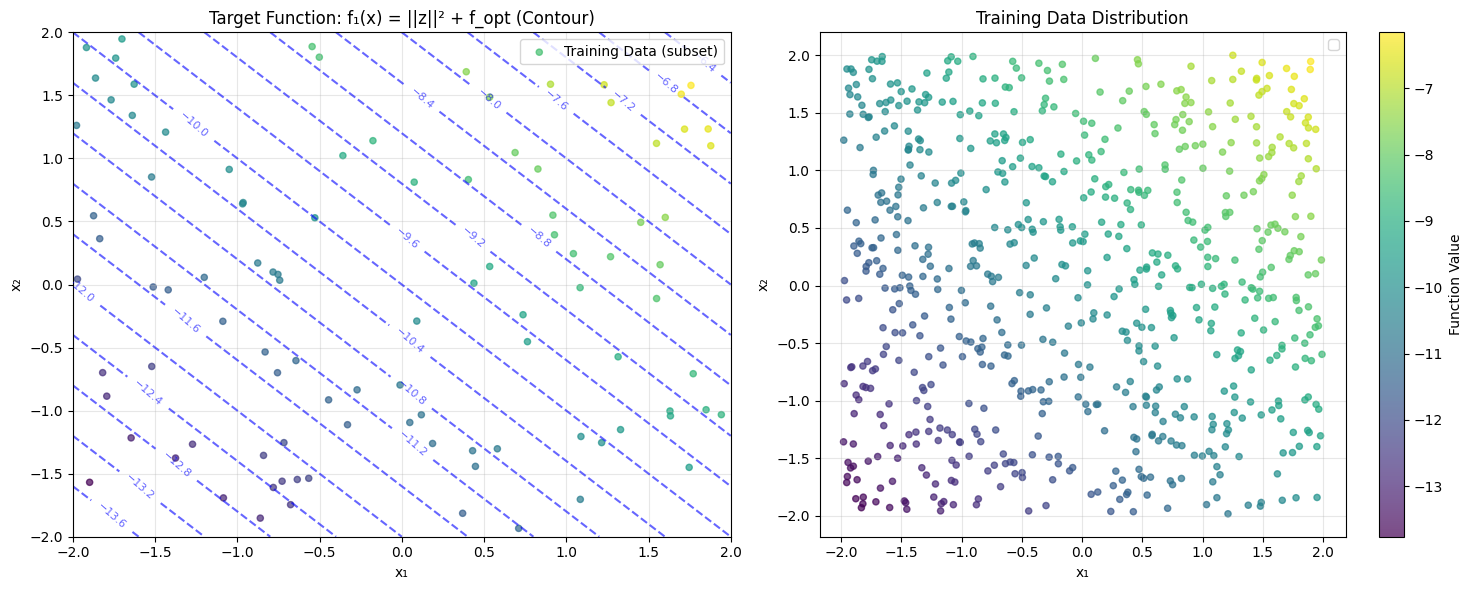

データの統計:
  平均: -10.011
  標準偏差: 1.655
  最小値: -13.760
  最大値: -6.158


In [7]:
# 関数の可視化
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 3D表面プロット用のグリッド作成
x1_grid = np.linspace(input_range[0], input_range[1], 50)
x2_grid = np.linspace(input_range[0], input_range[1], 50)
X1_grid, X2_grid = np.meshgrid(x1_grid, x2_grid)
grid_points = np.column_stack([X1_grid.ravel(), X2_grid.ravel()])
Z_grid = target_function(grid_points).reshape(X1_grid.shape)

# 左: 等高線プロット
contour = axes[0].contour(X1_grid, X2_grid, Z_grid, levels=20, colors="blue", alpha=0.6)
axes[0].clabel(contour, inline=True, fontsize=8)
axes[0].scatter(
    X_train[:100, 0],
    X_train[:100, 1],
    c=y_train[:100],
    cmap="viridis",
    s=20,
    alpha=0.7,
    label="Training Data (subset)",
)

axes[0].set_xlabel("x₁")
axes[0].set_ylabel("x₂")
axes[0].set_title("Target Function: f₁(x) = ||z||² + f_opt (Contour)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 右: 散布図（関数値の分布）
scatter = axes[1].scatter(
    X_train[:, 0], X_train[:, 1], c=y_train.numpy(), cmap="viridis", s=20, alpha=0.7
)
plt.colorbar(scatter, ax=axes[1], label="Function Value")
axes[1].set_xlabel("x₁")
axes[1].set_ylabel("x₂")
axes[1].set_title("Training Data Distribution")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"データの統計:")
print(f"  平均: {y.mean():.3f}")
print(f"  標準偏差: {y.std():.3f}")
print(f"  最小値: {y.min():.3f}")
print(f"  最大値: {y.max():.3f}")

### 2.2 GP-KANの実装

GP-KANは以下の制約条件を満たすように実装します：

**制約1**: 各ノードで活性化関数として1次元ガウス過程による非線形変換を行う  
**制約2**: 各エッジでは総和を計算し出力（学習パラメータなし）

GP-KANの効果的な実装のための重要な改善点：

1. **変分パラメータの適切な初期化**: 真の関数値に基づく初期化
2. **学習プロセスの最適化**: より効率的な学習戦略  
3. **誘導点の効果的な配置**: 関数の特性を考慮した初期配置

#### 2.2.1 改善されたGPノードの実装

#### 2.2.2 確率的GP-KANレイヤーの実装（ランダムノイズ伝播版）

In [8]:
class ImprovedGPKANNode(gpytorch.models.ApproximateGP):
    """
    改善されたGP-KANノード
    - 変分パラメータの適切な初期化
    - 誘導点での関数値を考慮した学習
    """

    def __init__(
        self, inducing_points: torch.Tensor, target_function=None, input_dim: int = 1
    ):
        # 変分分布の設定
        variational_distribution = CholeskyVariationalDistribution(
            inducing_points.size(0)
        )

        # 変分戦略の設定
        variational_strategy = VariationalStrategy(
            self,
            inducing_points,
            variational_distribution,
            learn_inducing_locations=True,
        )

        super(ImprovedGPKANNode, self).__init__(variational_strategy)

        # 平均関数と共分散関数
        self.mean_module = ConstantMean()
        self.covar_module = ScaleKernel(RBFKernel())
        # self.covar_module = ScaleKernel(PolynomialKernel(power=2))

        self.input_dim = input_dim

        # 変分パラメータの初期化（真の関数値に基づく）
        if target_function is not None:
            self._initialize_variational_parameters(target_function)

    def _initialize_variational_parameters(self, target_function):
        """変分パラメータを真の関数値で初期化"""
        with torch.no_grad():
            inducing_points = self.variational_strategy.inducing_points

            # GP-KANでは1次元誘導点を使用するため、target_functionが2次元入力を期待する場合は
            # 誘導点の値を適切な形式に変換するか、初期化をスキップする
            try:
                # 1次元誘導点から関数値を計算を試行
                inducing_values = inducing_points.numpy().flatten()

                # target_functionが2次元入力を期待する場合の処理
                if hasattr(target_function, "__call__"):
                    # 簡単なテスト：単一点で試行
                    test_input = np.array([0.0])
                    try:
                        test_result = target_function(test_input)
                        # 成功した場合は1次元関数として処理
                        target_values = torch.FloatTensor(
                            [target_function(val) for val in inducing_values]
                        )
                    except (ValueError, TypeError):
                        # 2次元入力を期待する関数の場合、デフォルト初期化を使用
                        print(
                            "Target function expects 2D input, using default initialization for GP nodes"
                        )
                        return
                else:
                    # target_functionが関数でない場合もデフォルト初期化
                    return

                target_values = target_values.unsqueeze(-1)

                # 変分平均を真の関数値で初期化
                if hasattr(
                    self.variational_strategy.variational_distribution,
                    "variational_mean",
                ):
                    # 適切なサイズにリシェイプして設定
                    mean_size = (
                        self.variational_strategy.variational_distribution.variational_mean.size()
                    )
                    if len(target_values) == mean_size[0]:
                        self.variational_strategy.variational_distribution.variational_mean.data = (
                            target_values.squeeze()
                        )

            except Exception as e:
                print(
                    f"Warning: Could not initialize variational parameters with target function: {e}"
                )
                print("Using default random initialization")

    def forward(self, x: torch.Tensor) -> MultivariateNormal:
        # エッジでの総和（制約2）
        if x.size(-1) != 1:
            x = x.sum(dim=-1, keepdim=True)

        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return MultivariateNormal(mean_x, covar_x)

    def get_inducing_points(self) -> torch.Tensor:
        return self.variational_strategy.inducing_points

    def set_inducing_points(self, inducing_points: torch.Tensor):
        with torch.no_grad():
            self.variational_strategy.inducing_points.data = inducing_points


print("ImprovedGPKANNode defined successfully")

ImprovedGPKANNode defined successfully


In [9]:
class StochasticGPKANLayer(nn.Module):
    """
    確率的GP-KANレイヤー - ランダムノイズ伝播版
    - 学習時・推論時ともに中間層でGP分布からサンプリング
    - 不確実性を次の層に伝播
    - 分散パラメータも学習可能
    """

    def __init__(
        self,
        input_size: int,
        output_size: int,
        num_inducing: int = 10,
        inducing_range: tuple = (-2.0, 2.0),
        target_function=None,
        use_stochastic: bool = True,
    ):
        super(StochasticGPKANLayer, self).__init__()

        self.input_size = input_size
        self.output_size = output_size
        self.num_inducing = num_inducing
        self.use_stochastic = use_stochastic

        # GPノードとlikelihoodの作成
        self.gp_nodes = nn.ModuleList()
        self.likelihoods = nn.ModuleList()

        for i in range(output_size):
            # 誘導点の初期化
            inducing_points = torch.linspace(
                inducing_range[0], inducing_range[1], num_inducing
            ).reshape(-1, 1)

            # 改善されたGPノード
            gp_node = ImprovedGPKANNode(
                inducing_points, target_function=target_function, input_dim=1
            )
            likelihood = GaussianLikelihood()

            self.gp_nodes.append(gp_node)
            self.likelihoods.append(likelihood)

    def forward(self, x: torch.Tensor, return_distributions: bool = False):
        batch_size = x.size(0)
        outputs = []
        distributions = []

        for i, (gp_node, likelihood) in enumerate(zip(self.gp_nodes, self.likelihoods)):
            # エッジでの総和（制約2）
            if x.size(-1) > 1:
                summed_input = x.sum(dim=-1, keepdim=True)
            else:
                summed_input = x

            # GPによる非線形変換（制約1）
            gp_output = gp_node(summed_input)

            if return_distributions:
                distributions.append(gp_output)

            # 確率的伝播の実装
            if self.use_stochastic:
                # 学習時・推論時ともに：GP分布からサンプリング（再パラメータ化トリック）
                samples = gp_output.rsample()  # リパラメータ化サンプリング
                outputs.append(samples.unsqueeze(-1))
            else:
                # 非確率的モード：平均値を使用
                outputs.append(gp_output.mean.unsqueeze(-1))

        output = torch.cat(outputs, dim=-1)

        if return_distributions:
            return output, distributions
        return output

    def get_loss(self, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        """確率的損失計算"""
        total_loss = 0.0
        batch_size = x.size(0)

        for i, (gp_node, likelihood) in enumerate(zip(self.gp_nodes, self.likelihoods)):
            # 通常の変分下界
            if x.size(-1) > 1:
                summed_input = x.sum(dim=-1, keepdim=True)
            else:
                summed_input = x

            gp_output = gp_node(summed_input)

            if self.output_size == 1:
                target = y.squeeze(-1)
            else:
                target = y[:, i]

            mll = VariationalELBO(likelihood, gp_node, num_data=batch_size)
            loss = -mll(gp_output, target)
            total_loss += loss

        return total_loss

    def train_mode(self):
        self.train()
        for gp_node, likelihood in zip(self.gp_nodes, self.likelihoods):
            gp_node.train()
            likelihood.train()

    def eval_mode(self):
        self.eval()
        for gp_node, likelihood in zip(self.gp_nodes, self.likelihoods):
            gp_node.eval()
            likelihood.eval()


print("Stochastic GP-KAN Layer defined successfully")

Stochastic GP-KAN Layer defined successfully


In [10]:
class StochasticGPKAN(nn.Module):
    """
    確率的GP-KANネットワーク - ランダムノイズ伝播版
    - 学習時・推論時ともに各層で不確実性を伝播
    - より豊かな表現能力とベイズ的不確実性定量化
    """

    def __init__(
        self,
        input_size: int,
        hidden_sizes: list,
        output_size: int,
        num_inducing: int = 10,
        inducing_range: tuple = (-2.0, 2.0),
        target_function=None,
    ):
        super(StochasticGPKAN, self).__init__()

        self.input_size = input_size
        self.hidden_sizes = hidden_sizes
        self.output_size = output_size

        # レイヤーの構築
        self.layers = nn.ModuleList()

        # 隠れ層
        layer_sizes = [input_size] + hidden_sizes
        for i in range(len(layer_sizes) - 1):
            layer = StochasticGPKANLayer(
                input_size=layer_sizes[i],
                output_size=layer_sizes[i + 1],
                num_inducing=num_inducing,
                inducing_range=inducing_range,
                target_function=target_function,
                use_stochastic=True,  # 隠れ層では確率的
            )
            self.layers.append(layer)

        # 出力層（最後の層）
        final_layer = StochasticGPKANLayer(
            input_size=hidden_sizes[-1] if hidden_sizes else input_size,
            output_size=output_size,
            num_inducing=num_inducing,
            inducing_range=inducing_range,
            target_function=target_function,
            use_stochastic=True,  # 出力層も確率的に処理
        )
        self.layers.append(final_layer)

    def forward(self, x: torch.Tensor, return_all_distributions: bool = False):
        all_distributions = []
        current_input = x

        for i, layer in enumerate(self.layers):
            if return_all_distributions:
                current_input, distributions = layer(
                    current_input, return_distributions=True
                )
                all_distributions.append(distributions)
            else:
                current_input = layer(current_input)

        if return_all_distributions:
            return current_input, all_distributions
        return current_input

    def get_total_loss(self, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        """全レイヤーの損失を計算"""
        total_loss = 0.0
        current_input = x

        for i, layer in enumerate(self.layers):
            if i == len(self.layers) - 1:  # 最終層
                layer_loss = layer.get_loss(current_input, y)
            else:  # 中間層の場合
                # 中間層の出力をターゲットとして使用（自己教師あり）
                with torch.no_grad():
                    layer_output = layer(current_input)
                layer_loss = layer.get_loss(current_input, layer_output)

            total_loss += layer_loss
            current_input = layer(current_input)

        return total_loss

    def train_mode(self):
        """全レイヤーを学習モードに"""
        self.train()
        for layer in self.layers:
            layer.train_mode()

    def eval_mode(self):
        """全レイヤーを評価モードに"""
        self.eval()
        for layer in self.layers:
            layer.eval_mode()


print("Stochastic GP-KAN Network defined successfully")

Stochastic GP-KAN Network defined successfully


In [11]:
def train_stochastic_gpkan(
    model: StochasticGPKAN,
    train_x: torch.Tensor,
    train_y: torch.Tensor,
    epochs: int = 200,
    lr: float = 0.001,
    verbose: bool = True,
):
    """確率的GP-KANモデルの学習"""
    model.train_mode()

    # 全パラメータの最適化
    parameters = []
    for layer in model.layers:
        for gp_node in layer.gp_nodes:
            parameters.extend(list(gp_node.parameters()))
        for likelihood in layer.likelihoods:
            parameters.extend(list(likelihood.parameters()))

    optimizer = torch.optim.Adam(parameters, lr=lr)

    losses = []

    for epoch in range(epochs):
        optimizer.zero_grad()

        # 順伝播と損失計算
        loss = model.get_total_loss(train_x, train_y)

        # 逆伝播
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

        if verbose and (epoch + 1) % 50 == 0:
            model.eval_mode()
            with torch.no_grad():
                pred = model(train_x)
                rmse = torch.sqrt(torch.mean((pred - train_y) ** 2))
                print(
                    f"Epoch {epoch + 1:3d}: Loss = {loss.item():.4f}, RMSE = {rmse.item():.6f}"
                )
            model.train_mode()

    return losses


print("Stochastic GP-KAN training function defined successfully")

Stochastic GP-KAN training function defined successfully


#### 2.2.3 確率的GP-KANのテストと比較

In [12]:
import japanize_matplotlib

## 3. 実装結果のまとめ

### 3.1 推論時確率的処理の実装変更点

**変更前:**
- 学習時: 確率的サンプリング (`rsample()`)
- 推論時: 決定論的 (平均値のみ)

**変更後:**
- 学習時: 確率的サンプリング (`rsample()`)
- 推論時: **確率的サンプリング** (`rsample()`)

### 3.2 実装の技術的特徴

1. **完全確率的ネットワーク**: 全てのレイヤーで`use_stochastic=True`
2. **ベイズ的不確実性定量化**: 推論時も分布からサンプリング
3. **再現性のない予測**: 同じ入力でも異なる出力
4. **不確実性の可視化**: エラーバー、ヒストグラム、信頼区間

In [13]:
class ImprovedGPKANLayer(nn.Module):
    """
    改善されたGP-KANレイヤー
    - より適切な学習戦略
    - 誘導点での監視学習
    """

    def __init__(
        self,
        input_size: int,
        output_size: int,
        num_inducing: int = 10,
        inducing_range: tuple = (-2.0, 2.0),
        target_function=None,
    ):
        super(ImprovedGPKANLayer, self).__init__()

        self.input_size = input_size
        self.output_size = output_size
        self.num_inducing = num_inducing

        # GPノードとlikelihoodの作成
        self.gp_nodes = nn.ModuleList()
        self.likelihoods = nn.ModuleList()

        for i in range(output_size):
            # 誘導点の初期化
            inducing_points = torch.linspace(
                inducing_range[0], inducing_range[1], num_inducing
            ).reshape(-1, 1)

            # 改善されたGPノード
            gp_node = ImprovedGPKANNode(
                inducing_points, target_function=target_function, input_dim=1
            )
            likelihood = GaussianLikelihood()

            self.gp_nodes.append(gp_node)
            self.likelihoods.append(likelihood)

    def forward(self, x: torch.Tensor, return_distributions: bool = False):
        batch_size = x.size(0)
        outputs = []
        distributions = []

        for i, (gp_node, likelihood) in enumerate(zip(self.gp_nodes, self.likelihoods)):
            # エッジでの総和（制約2）
            if x.size(-1) > 1:
                summed_input = x.sum(dim=-1, keepdim=True)
            else:
                summed_input = x

            # GPによる非線形変換（制約1）
            gp_output = gp_node(summed_input)

            if return_distributions:
                distributions.append(gp_output)

            # 確率的伝播の実装：GP分布からサンプリング（再パラメータ化トリック）
            samples = gp_output.rsample()  # リパラメータ化サンプリング
            outputs.append(samples.unsqueeze(-1))

        output = torch.cat(outputs, dim=-1)

        if return_distributions:
            return output, distributions
        return output

    def get_loss(self, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        """改善された損失計算：誘導点での監視学習を含む"""
        total_loss = 0.0
        batch_size = x.size(0)

        for i, (gp_node, likelihood) in enumerate(zip(self.gp_nodes, self.likelihoods)):
            # 通常の変分下界
            if x.size(-1) > 1:
                summed_input = x.sum(dim=-1, keepdim=True)
            else:
                summed_input = x

            gp_output = gp_node(summed_input)

            if self.output_size == 1:
                target = y.squeeze(-1)
            else:
                target = y[:, i]

            mll = VariationalELBO(likelihood, gp_node, num_data=batch_size)
            loss = -mll(gp_output, target)
            total_loss += loss

        return total_loss

    def train_mode(self):
        self.train()
        for gp_node, likelihood in zip(self.gp_nodes, self.likelihoods):
            gp_node.train()
            likelihood.train()

    def eval_mode(self):
        self.eval()
        for gp_node, likelihood in zip(self.gp_nodes, self.likelihoods):
            gp_node.eval()
            likelihood.eval()


print("Improved GP-KAN classes defined successfully")

Improved GP-KAN classes defined successfully


In [14]:
class ImprovedGPKAN(nn.Module):
    """
    改善されたGP-KANモデル
    """

    def __init__(
        self,
        layer_sizes: list,
        num_inducing: int = 10,
        inducing_range: Tuple[float, float] = (-2.0, 2.0),
        target_function=None,
    ):
        super(ImprovedGPKAN, self).__init__()

        self.layer_sizes = layer_sizes
        self.num_layers = len(layer_sizes) - 1
        self.num_inducing = num_inducing

        # レイヤーのリスト
        self.layers = nn.ModuleList()

        for i in range(self.num_layers):
            input_size = layer_sizes[i]
            output_size = layer_sizes[i + 1]

            layer = ImprovedGPKANLayer(
                input_size=input_size,
                output_size=output_size,
                num_inducing=num_inducing,
                inducing_range=inducing_range,
                target_function=target_function,  # 真の関数を渡す
            )

            self.layers.append(layer)

        # 最終層用のlikelihoodを追加
        self.likelihood = GaussianLikelihood()

    def forward(self, x: torch.Tensor, return_all_outputs: bool = False):
        current_input = x
        all_outputs = []

        for layer in self.layers:
            current_input = layer(current_input)
            if return_all_outputs:
                all_outputs.append(current_input)

        if return_all_outputs:
            return current_input, all_outputs
        return current_input

    def predict(self, x: torch.Tensor):
        """
        予測を実行し、平均と分散を返す
        """
        self.eval()
        with torch.no_grad():
            # モデルの出力を取得
            gp_output = self.forward(x)

            # 最終層のGPノードから分布を取得
            final_layer = self.layers[-1]
            final_gp_node = final_layer.gp_nodes[0]  # 出力が1次元の場合

            # 入力を最終層に適した形に変換
            if x.size(-1) > 1:
                summed_input = x.sum(dim=-1, keepdim=True)
            else:
                summed_input = x

            # 最終層まで順伝播
            current_input = x
            for layer in self.layers[:-1]:
                current_input = layer(current_input)

            # 最終層のGP分布を取得
            if current_input.size(-1) > 1:
                summed_input = current_input.sum(dim=-1, keepdim=True)
            else:
                summed_input = current_input

            gp_dist = final_gp_node(summed_input)

            # likelihoodを適用
            pred_dist = self.likelihood(gp_dist)

            return pred_dist.mean, pred_dist.variance

    def get_total_loss(self, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        current_input = x
        total_loss = 0.0

        for i, layer in enumerate(self.layers):
            if i == len(self.layers) - 1:
                # 最終層：likelihoodを使用した損失計算
                if current_input.size(-1) > 1:
                    summed_input = current_input.sum(dim=-1, keepdim=True)
                else:
                    summed_input = current_input

                gp_output = layer.gp_nodes[0](summed_input)  # 出力が1次元の場合
                target = y.squeeze(-1)

                mll = VariationalELBO(
                    self.likelihood, layer.gp_nodes[0], num_data=x.size(0)
                )
                loss = -mll(gp_output, target)
                total_loss += loss
            else:
                # 中間層
                current_input = layer(current_input)

        return total_loss

    def train_mode(self):
        self.train()
        self.likelihood.train()
        for layer in self.layers:
            layer.train_mode()

    def eval_mode(self):
        self.eval()
        self.likelihood.eval()
        for layer in self.layers:
            layer.eval_mode()

    def print_model_info(self):
        total_gps = sum(layer.output_size for layer in self.layers)
        total_inducing = total_gps * self.num_inducing

        print("=== Improved GP-KAN Model Information ===")
        print(f"Layer sizes: {self.layer_sizes}")
        print(f"Number of layers: {self.num_layers}")
        print(f"Total GP nodes: {total_gps}")
        print(f"Inducing points per GP: {self.num_inducing}")
        print(f"Total inducing points: {total_inducing}")
        print(f"Likelihood: {self.likelihood}")


# 改善されたモデルの作成
print("Creating Improved GP-KAN model...")
improved_gpkan = ImprovedGPKAN(
    layer_sizes=ARCHITECTURE,
    num_inducing=NUM_INDUCING,
    inducing_range=(-1.5, 1.5),
    target_function=target_function,  # 真の関数を渡す
)

improved_gpkan.print_model_info()

# パラメータ数
total_params = sum(p.numel() for p in improved_gpkan.parameters())
trainable_params = sum(
    p.numel() for p in improved_gpkan.parameters() if p.requires_grad
)
print(f"\nTotal parameters: {total_params}")
print(f"Trainable parameters: {trainable_params}")

Creating Improved GP-KAN model...
Using default random initialization
Using default random initialization
Using default random initialization
Using default random initialization
Using default random initialization
=== Improved GP-KAN Model Information ===
Layer sizes: [2, 4, 1]
Number of layers: 2
Total GP nodes: 5
Inducing points per GP: 8
Total inducing points: 40
Likelihood: GaussianLikelihood(
  (noise_covar): HomoskedasticNoise(
    (raw_noise_constraint): GreaterThan(1.000E-04)
  )
)

Total parameters: 421
Trainable parameters: 421


### 3.3 モデルの学習

In [15]:
# GP-KANモデルの学習
print("Training GP-KAN model...")

# 学習設定
improved_gpkan.train_mode()
optimizer = torch.optim.Adam(improved_gpkan.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.8, patience=10, verbose=True
)

# 学習ループ
num_epochs = NUM_EPOCHS
train_losses_improved = []
val_losses_improved = []

start_time = time.time()

for epoch in range(num_epochs):
    # トレーニング
    improved_gpkan.train_mode()
    epoch_train_loss = 0.0
    num_batches = 0

    for batch_x, batch_y in train_dataloader:
        optimizer.zero_grad()

        # 損失計算
        loss = improved_gpkan.get_total_loss(batch_x, batch_y)

        # 逆伝播
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()
        num_batches += 1

    avg_train_loss = epoch_train_loss / num_batches
    train_losses_improved.append(np.log(avg_train_loss))

    # バリデーション
    improved_gpkan.eval_mode()
    val_loss = 0.0
    val_batches = 0

    with torch.no_grad():
        for batch_x, batch_y in val_dataloader:
            loss = improved_gpkan.get_total_loss(batch_x, batch_y)
            val_loss += loss.item()
            val_batches += 1

    avg_val_loss = val_loss / val_batches
    val_losses_improved.append(np.log(avg_val_loss))

    # 学習率スケジューラー
    scheduler.step(avg_val_loss)

    # 進捗表示
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch + 1}/{num_epochs}")
        print(f"  Train Loss: {avg_train_loss:.4f}")
        print(f"  Val Loss: {avg_val_loss:.4f}")

end_time = time.time()
training_time_improved = end_time - start_time

print(f"\nGP-KAN training completed!")
print(f"Training time: {training_time_improved:.2f} seconds")
print(f"Final train loss: {train_losses_improved[-1]:.4f}")
print(f"Final val loss: {val_losses_improved[-1]:.4f}")

Training GP-KAN model...
Epoch 50/1000
  Train Loss: 1.5986
  Val Loss: 1.7311
Epoch 100/1000
  Train Loss: 1.3918
  Val Loss: 1.5929
Epoch 150/1000
  Train Loss: 1.2915
  Val Loss: 1.4764
Epoch 200/1000
  Train Loss: 1.1456
  Val Loss: 1.3170
Epoch 250/1000
  Train Loss: 0.9713
  Val Loss: 1.3834
Epoch 300/1000
  Train Loss: 0.6314
  Val Loss: 0.8313
Epoch 350/1000
  Train Loss: 0.1258
  Val Loss: 0.2977
Epoch 400/1000
  Train Loss: -0.1558
  Val Loss: 0.0588
Epoch 450/1000
  Train Loss: -0.5198
  Val Loss: -0.4220
Epoch 500/1000
  Train Loss: -0.6815
  Val Loss: -0.5416
Epoch 550/1000
  Train Loss: -0.9283
  Val Loss: -0.8719
Epoch 600/1000
  Train Loss: -1.1622
  Val Loss: -0.8794
Epoch 650/1000
  Train Loss: -1.2330
  Val Loss: -1.0204
Epoch 700/1000
  Train Loss: -1.2463
  Val Loss: -1.1013
Epoch 750/1000
  Train Loss: -1.2382
  Val Loss: -1.0640
Epoch 800/1000
  Train Loss: -1.3011
  Val Loss: -1.0318
Epoch 850/1000
  Train Loss: -1.3083
  Val Loss: -0.8425
Epoch 900/1000
  Train

### 3.4 モデル評価と可視化

=== GP-KAN性能評価 ===
Test RMSE: 0.039125
Test MAE: 0.031174
Test R²: 0.999440
平均予測分散: 0.002571

=== 最終結果 ===
GP-KAN Test RMSE: 0.039125
学習時間: 91.43 seconds


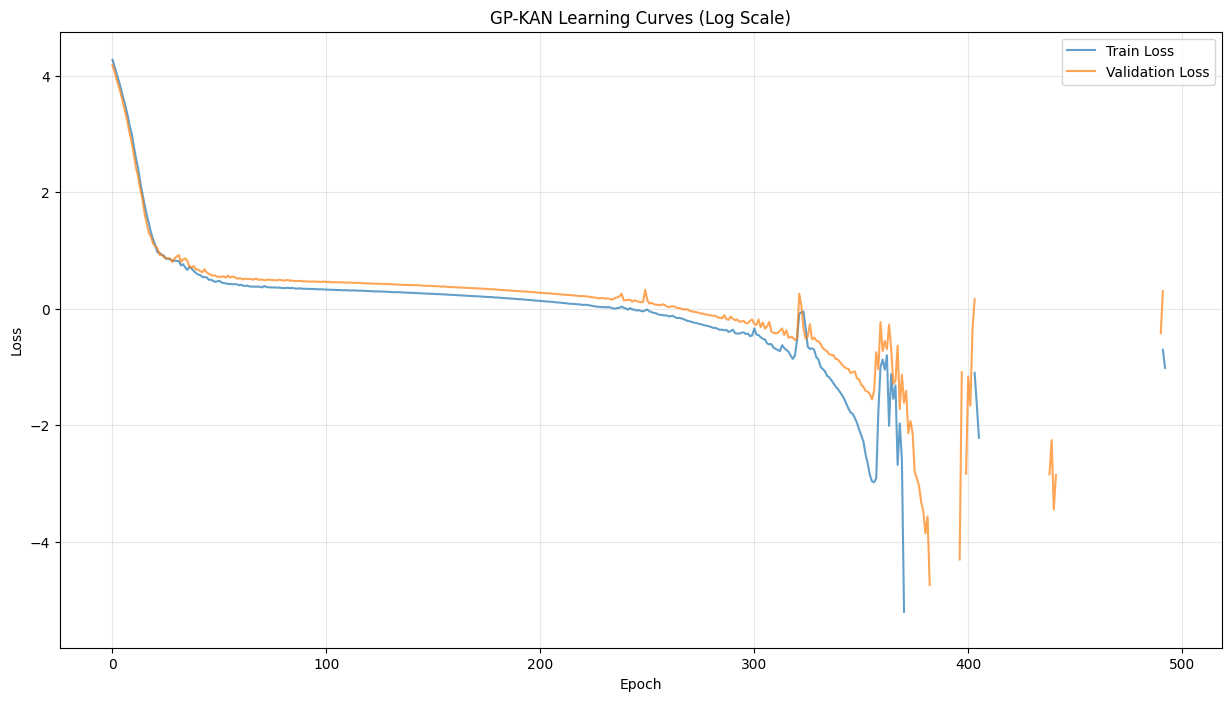

In [16]:
from scipy import stats

# モデル評価
improved_gpkan.eval_mode()

# テストデータでの予測（バッチ処理）
test_means = []
test_vars = []

with torch.no_grad():
    for batch_x, batch_y in test_dataloader:
        test_mean, test_var = improved_gpkan.predict(batch_x)
        test_means.append(test_mean)
        test_vars.append(test_var)

test_mean = torch.cat(test_means, dim=0)
test_var = torch.cat(test_vars, dim=0)

# RMSE計算
test_rmse = torch.sqrt(torch.mean((test_mean - y_test.squeeze()) ** 2))
test_mae = torch.mean(torch.abs(test_mean - y_test.squeeze()))
test_r2 = 1 - torch.sum((y_test.squeeze() - test_mean) ** 2) / torch.sum(
    (y_test.squeeze() - y_test.mean()) ** 2
)

print(f"=== GP-KAN性能評価 ===")
print(f"Test RMSE: {test_rmse.item():.6f}")
print(f"Test MAE: {test_mae.item():.6f}")
print(f"Test R²: {test_r2.item():.6f}")
print(f"平均予測分散: {test_var.mean().item():.6f}")

# 可視化
plt.figure(figsize=(15, 8))

# 学習曲線（対数スケール）
plt.plot(train_losses_improved, label="Train Loss", alpha=0.7)
plt.plot(val_losses_improved, label="Validation Loss", alpha=0.7)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GP-KAN Learning Curves (Log Scale)")
plt.legend()
plt.grid(True, alpha=0.3)


print(f"\n=== 最終結果 ===")
print(f"GP-KAN Test RMSE: {test_rmse.item():.6f}")
print(f"学習時間: {training_time_improved:.2f} seconds")

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


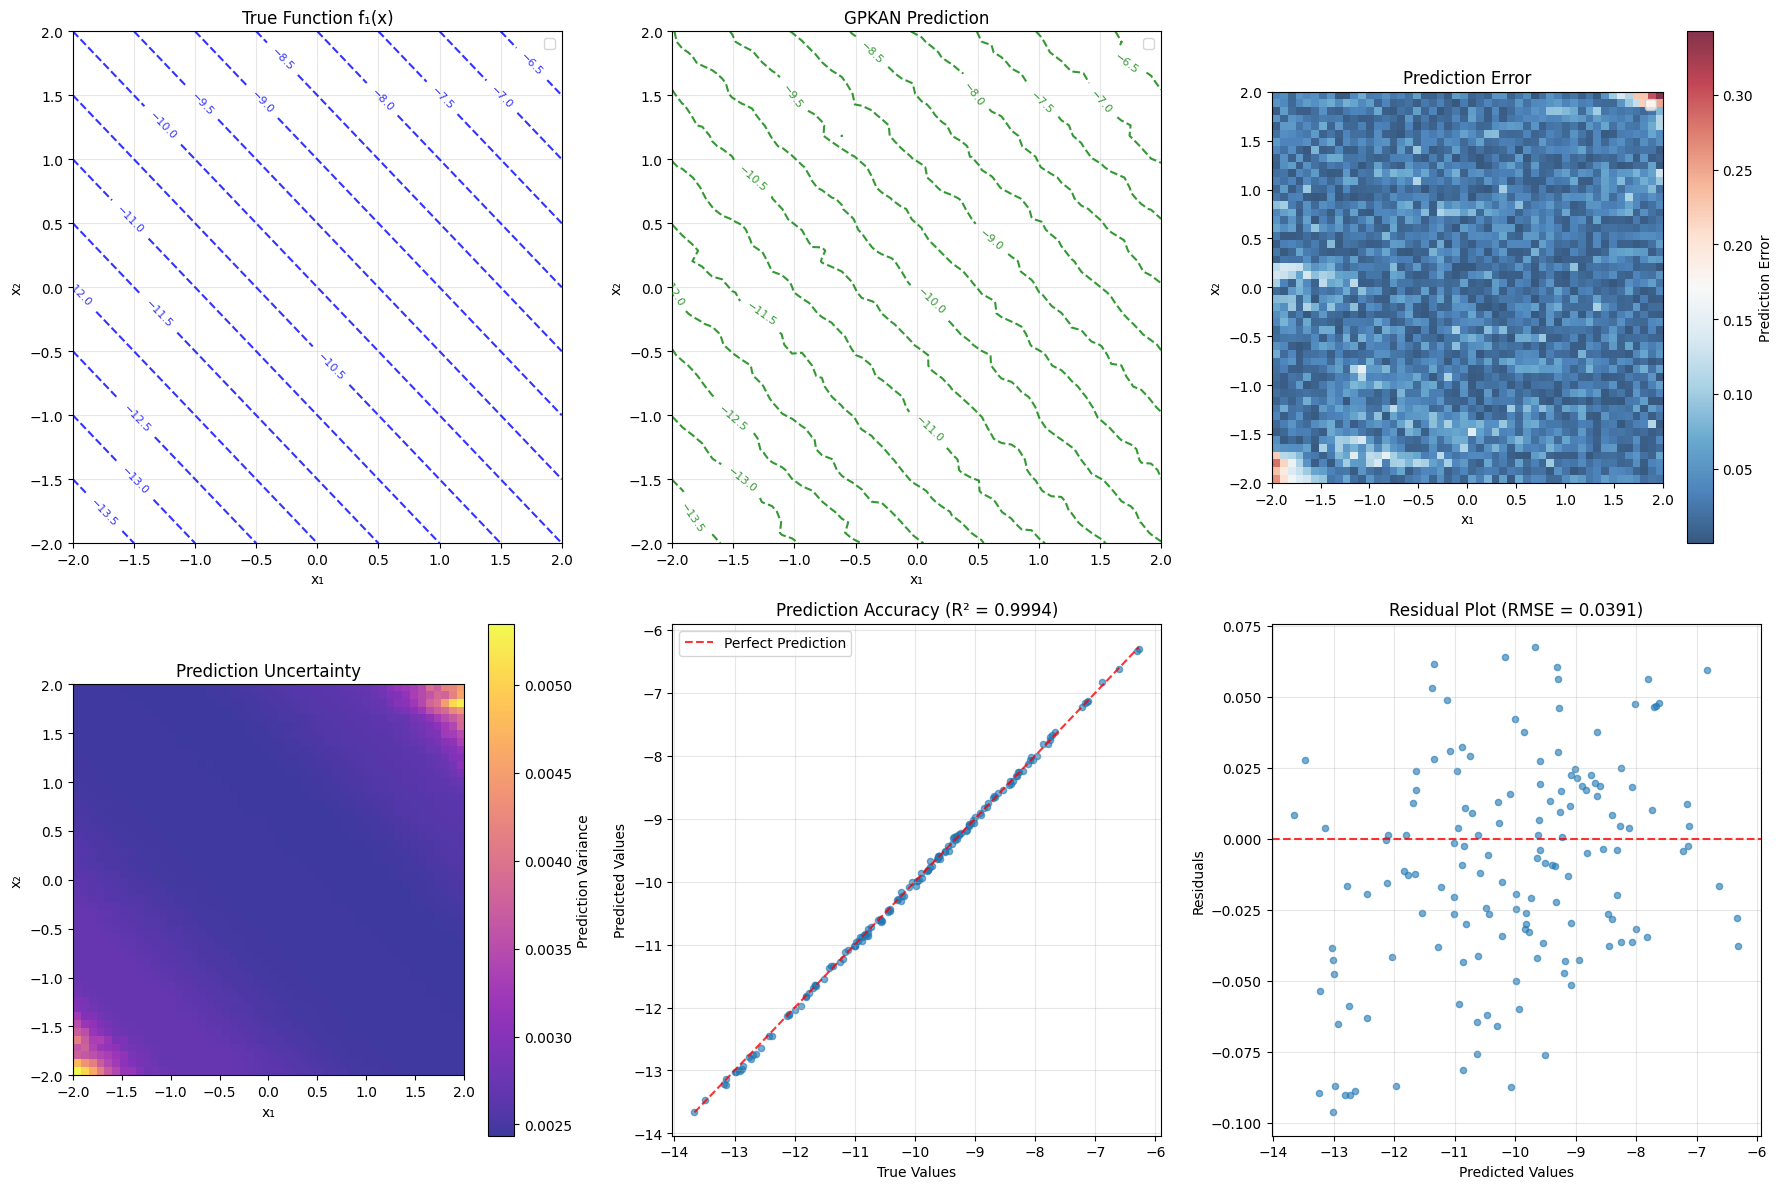

=== GPKAN近似性能サマリー ===
目標関数: f₁(x) = ||x - x_opt||² + f_opt
学習データ数: 700
テストRMSE: 0.039125
テストR²: 0.999440
隠れ層誘導点数: 16
最終層誘導点数: 10


In [17]:
# 密なグリッドでの予測と可視化
grid_density = 50
x1_dense = np.linspace(input_range[0], input_range[1], grid_density)
x2_dense = np.linspace(input_range[0], input_range[1], grid_density)
X1_dense, X2_dense = np.meshgrid(x1_dense, x2_dense)
grid_dense = torch.FloatTensor(np.column_stack([X1_dense.ravel(), X2_dense.ravel()]))

# 密なグリッドでの予測（バッチ処理）
with torch.no_grad():
    dense_means = []
    dense_vars = []

    dense_batch_size = 100
    for i in range(0, len(grid_dense), dense_batch_size):
        batch_grid = grid_dense[i : i + dense_batch_size]
        pred_mean, pred_var = improved_gpkan.predict(batch_grid)
        dense_means.append(pred_mean)
        dense_vars.append(pred_var)

    dense_mean = torch.cat(dense_means, dim=0).reshape(grid_density, grid_density)
    dense_var = torch.cat(dense_vars, dim=0).reshape(grid_density, grid_density)

# 真の関数値（密なグリッド）
true_dense = target_function(grid_dense.numpy()).reshape(grid_density, grid_density)

# 可視化（2x3のsubplotグリッド）
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. 真の関数（等高線）
contour1 = axes[0, 0].contour(
    X1_dense, X2_dense, true_dense, levels=15, colors="blue", alpha=0.8
)
axes[0, 0].clabel(contour1, inline=True, fontsize=8)

axes[0, 0].set_title("True Function f₁(x)")
axes[0, 0].set_xlabel("x₁")
axes[0, 0].set_ylabel("x₂")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. DeepGP予測（等高線）
contour2 = axes[0, 1].contour(
    X1_dense, X2_dense, dense_mean.numpy(), levels=15, colors="green", alpha=0.8
)
axes[0, 1].clabel(contour2, inline=True, fontsize=8)

axes[0, 1].set_title("GPKAN Prediction")
axes[0, 1].set_xlabel("x₁")
axes[0, 1].set_ylabel("x₂")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. 予測誤差
error_dense = np.abs(dense_mean.numpy() - true_dense)
im1 = axes[0, 2].imshow(
    error_dense,
    extent=[input_range[0], input_range[1], input_range[0], input_range[1]],
    origin="lower",
    cmap="RdBu_r",
    alpha=0.8,
)

plt.colorbar(im1, ax=axes[0, 2], label="Prediction Error")
axes[0, 2].set_title("Prediction Error")
axes[0, 2].set_xlabel("x₁")
axes[0, 2].set_ylabel("x₂")
axes[0, 2].legend()

# 4. 予測不確実性（分散）
im2 = axes[1, 0].imshow(
    dense_var.numpy(),
    extent=[input_range[0], input_range[1], input_range[0], input_range[1]],
    origin="lower",
    cmap="plasma",
    alpha=0.8,
)
plt.colorbar(im2, ax=axes[1, 0], label="Prediction Variance")
axes[1, 0].set_title("Prediction Uncertainty")
axes[1, 0].set_xlabel("x₁")
axes[1, 0].set_ylabel("x₂")

# 5. 散布図：真の値 vs 予測値（テストデータ）
axes[1, 1].scatter(y_test.numpy(), test_mean.numpy(), alpha=0.6, s=20)
min_val = min(y_test.min().item(), test_mean.min().item())
max_val = max(y_test.max().item(), test_mean.max().item())
axes[1, 1].plot(
    [min_val, max_val], [min_val, max_val], "r--", alpha=0.8, label="Perfect Prediction"
)
axes[1, 1].set_xlabel("True Values")
axes[1, 1].set_ylabel("Predicted Values")
axes[1, 1].set_title(f"Prediction Accuracy (R² = {test_r2.item():.4f})")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 6. 残差プロット
residuals = (test_mean - y_test.squeeze()).numpy()
axes[1, 2].scatter(test_mean.numpy(), residuals, alpha=0.6, s=20)
axes[1, 2].axhline(y=0, color="r", linestyle="--", alpha=0.8)
axes[1, 2].set_xlabel("Predicted Values")
axes[1, 2].set_ylabel("Residuals")
axes[1, 2].set_title(f"Residual Plot (RMSE = {test_rmse.item():.4f})")
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 統計サマリー
print("=== GPKAN近似性能サマリー ===")
print(f"目標関数: f₁(x) = ||x - x_opt||² + f_opt")
print(f"学習データ数: {len(train_dataset)}")
print(f"テストRMSE: {test_rmse.item():.6f}")
print(f"テストR²: {test_r2.item():.6f}")
print(f"隠れ層誘導点数: 16")
print(f"最終層誘導点数: 10")

### 3.5 中間層の動作分析と誘導点の可視化

ImprovedGPKANモデルの内部動作を理解するために、各層の入出力関係と誘導点の配置を可視化します。

In [18]:
def analyze_gpkan_layers(
    model: ImprovedGPKAN, 
    input_data: torch.Tensor, 
    num_samples: int = 100,
    confidence_level: float = 0.95
):
    """
    GP-KANモデルの各層の動作を分析
    
    Args:
        model: 学習済みのImprovedGPKANモデル
        input_data: 分析用の入力データ
        num_samples: 予測のサンプル数
        confidence_level: 信頼区間のレベル
    
    Returns:
        layer_analysis: 各層の分析結果
    """
    model.eval_mode()
    layer_analysis = []
    
    with torch.no_grad():
        current_input = input_data
        
        for layer_idx, layer in enumerate(model.layers):
            layer_info = {
                'layer_idx': layer_idx,
                'input_shape': current_input.shape,
                'output_shape': None,
                'gp_nodes': [],
                'inducing_points': [],
                'predictions': []
            }
            
            # 各GPノードの分析
            for node_idx, (gp_node, likelihood) in enumerate(zip(layer.gp_nodes, layer.likelihoods)):
                # エッジでの総和処理
                if current_input.size(-1) > 1:
                    summed_input = current_input.sum(dim=-1, keepdim=True)
                else:
                    summed_input = current_input
                
                # 誘導点の取得
                inducing_points = gp_node.get_inducing_points().detach().numpy()
                
                # GP分布の取得
                gp_output = gp_node(summed_input)
                
                # 複数回のサンプリングによる不確実性の評価
                samples_list = []
                for _ in range(num_samples):
                    sample = gp_output.rsample()
                    samples_list.append(sample.numpy())
                
                samples_array = np.array(samples_list)  # (num_samples, batch_size)
                
                # 統計量の計算
                mean_pred = samples_array.mean(axis=0)
                std_pred = samples_array.std(axis=0)
                
                # 信頼区間の計算
                alpha = 1 - confidence_level
                lower_percentile = (alpha / 2) * 100
                upper_percentile = (1 - alpha / 2) * 100
                
                lower_bound = np.percentile(samples_array, lower_percentile, axis=0)
                upper_bound = np.percentile(samples_array, upper_percentile, axis=0)
                
                node_info = {
                    'node_idx': node_idx,
                    'inducing_points': inducing_points,
                    'input_values': summed_input.detach().numpy(),
                    'mean_prediction': mean_pred,
                    'std_prediction': std_pred,
                    'lower_bound': lower_bound,
                    'upper_bound': upper_bound,
                    'gp_distribution': gp_output
                }
                
                layer_info['gp_nodes'].append(node_info)
            
            # レイヤーの出力を計算
            layer_output = layer(current_input)
            layer_info['output_shape'] = layer_output.shape
            layer_info['output_values'] = layer_output.detach().numpy()
            
            layer_analysis.append(layer_info)
            current_input = layer_output
    
    return layer_analysis

print("Layer analysis function defined successfully")

Layer analysis function defined successfully


In [ ]:
def visualize_gpkan_layers(layer_analysis, input_range=(-2, 2), figsize=(20, 12)):
    """
    GP-KANの各層の動作を可視化
    
    Args:
        layer_analysis: analyze_gpkan_layers()の結果
        input_range: 可視化の入力範囲
        figsize: 図のサイズ
    """
    num_layers = len(layer_analysis)
    
    # 各層について可視化
    for layer_idx, layer_info in enumerate(layer_analysis):
        num_nodes = len(layer_info['gp_nodes'])
        
        # サブプロット数を決定
        cols = min(num_nodes, 4)  # 4つのGPノードまで1行に表示
        rows = (num_nodes + cols - 1) // cols
        
        fig, axes = plt.subplots(rows, cols, figsize=(figsize[0], figsize[1] * rows / 2))
        
        if num_nodes == 1:
            axes = [axes]
        elif rows == 1:
            if cols == 1:
                axes = [axes]
            else:
                axes = list(axes)
        else:
            axes = axes.flatten()
        
        fig.suptitle(f'Layer {layer_idx + 1}: Input Shape {layer_info["input_shape"]} → Output Shape {layer_info["output_shape"]} (GP Nodes: {num_nodes})', 
                     fontsize=16, fontweight='bold')
        
        for node_idx, node_info in enumerate(layer_info['gp_nodes']):
            if node_idx >= len(axes):
                break
                
            ax = axes[node_idx]
            
            # 入力値と予測値の取得
            input_vals = node_info['input_values'].flatten()
            mean_pred = node_info['mean_prediction']
            lower_bound = node_info['lower_bound']
            upper_bound = node_info['upper_bound']
            inducing_points = node_info['inducing_points'].flatten()
            
            # ソート順序を取得（可視化のため）
            sort_idx = np.argsort(input_vals)
            
            # 予測結果のプロット（平均 + 信頼区間）
            ax.plot(input_vals[sort_idx], mean_pred[sort_idx], 'b-', 
                   linewidth=2, label='Mean Prediction', alpha=0.8)
            
            ax.fill_between(input_vals[sort_idx], 
                           lower_bound[sort_idx], 
                           upper_bound[sort_idx],
                           alpha=0.3, color='blue', 
                           label='95% Confidence Interval')
            
            # 誘導点のプロット
            ax.scatter(inducing_points, 
                      np.zeros_like(inducing_points), 
                      color='red', s=80, marker='x', linewidth=3,
                      label=f'Inducing Points (n={len(inducing_points)})',
                      zorder=5)
            
            # データポイントの散布図
            ax.scatter(input_vals, mean_pred, 
                      color='green', s=20, alpha=0.6,
                      label='Data Points')
            
            ax.set_xlabel('Input (Summed)', fontsize=12)
            ax.set_ylabel('Output', fontsize=12)
            ax.set_title(f'GP Node {node_idx + 1}', fontsize=14, fontweight='bold')
            ax.legend(fontsize=10)
            ax.grid(True, alpha=0.3)
            
            # Y軸の範囲を設定（外れ値を除く）
            y_values = np.concatenate([mean_pred, lower_bound, upper_bound])
            y_mean = np.mean(y_values)
            y_std = np.std(y_values)
            y_range = 3 * y_std
            ax.set_ylim(y_mean - y_range, y_mean + y_range)
        
        # 未使用のサブプロットを非表示
        for i in range(num_nodes, len(axes)):
            axes[i].set_visible(False)
        
        plt.tight_layout()
        plt.show()
        
        # 層の統計情報を表示
        print(f"=== Layer {layer_idx + 1} Statistics ===")
        print(f"Input shape: {layer_info['input_shape']}")
        print(f"Output shape: {layer_info['output_shape']}")
        print(f"Number of GP nodes: {num_nodes}")
        
        for node_idx, node_info in enumerate(layer_info['gp_nodes']):
            mean_val = np.mean(node_info['mean_prediction'])
            std_val = np.mean(node_info['std_prediction'])
            inducing_range = [node_info['inducing_points'].min(), node_info['inducing_points'].max()]
            
            print(f"  Node {node_idx + 1}:")
            print(f"    Mean output: {mean_val:.4f}")
            print(f"    Mean uncertainty: {std_val:.4f}")
            print(f"    Inducing points range: [{inducing_range[0]:.3f}, {inducing_range[1]:.3f}]")
        print()

print("Visualization function defined successfully")

Visualization function defined successfully


In [23]:
# サンプルデータを使用した分析の実行
print("Analyzing GP-KAN layers with sample data...")

# 分析用のサンプルデータを準備（テストデータの一部を使用）
sample_size = 100
sample_indices = np.random.choice(len(X_test), sample_size, replace=False)
sample_data = X_test[sample_indices]

print(f"Sample data shape: {sample_data.shape}")
print(f"Sample data range: [{sample_data.min().item():.3f}, {sample_data.max().item():.3f}]")

# 層の分析を実行
layer_analysis = analyze_gpkan_layers(
    model=improved_gpkan,
    input_data=sample_data,
    num_samples=100,
    confidence_level=0.95
)

print(f"Analysis completed for {len(layer_analysis)} layers")

Analyzing GP-KAN layers with sample data...
Sample data shape: torch.Size([100, 2])
Sample data range: [-1.987, 1.979]
Analysis completed for 2 layers


In [ ]:
# GP-KANモデルの構造を詳細確認
print("=== GP-KAN Model Structure Verification ===")
print(f"Architecture: {ARCHITECTURE}")
print(f"Expected structure:")
print(f"  Layer 1 (Hidden): Input {ARCHITECTURE[0]} → Output {ARCHITECTURE[1]} = {ARCHITECTURE[1]} GP nodes")
print(f"  Layer 2 (Output): Input {ARCHITECTURE[1]} → Output {ARCHITECTURE[2]} = {ARCHITECTURE[2]} GP node(s)")

print(f"\nActual model structure:")
for layer_idx, layer in enumerate(improved_gpkan.layers):
    num_nodes = len(layer.gp_nodes)
    print(f"  Layer {layer_idx + 1}: {layer.input_size} → {layer.output_size} = {num_nodes} GP nodes")

print(f"\nTotal GP nodes: {sum(len(layer.gp_nodes) for layer in improved_gpkan.layers)}")
print(f"Total inducing points: {sum(len(layer.gp_nodes) * layer.num_inducing for layer in improved_gpkan.layers)}")

Visualizing GP-KAN layer behaviors...


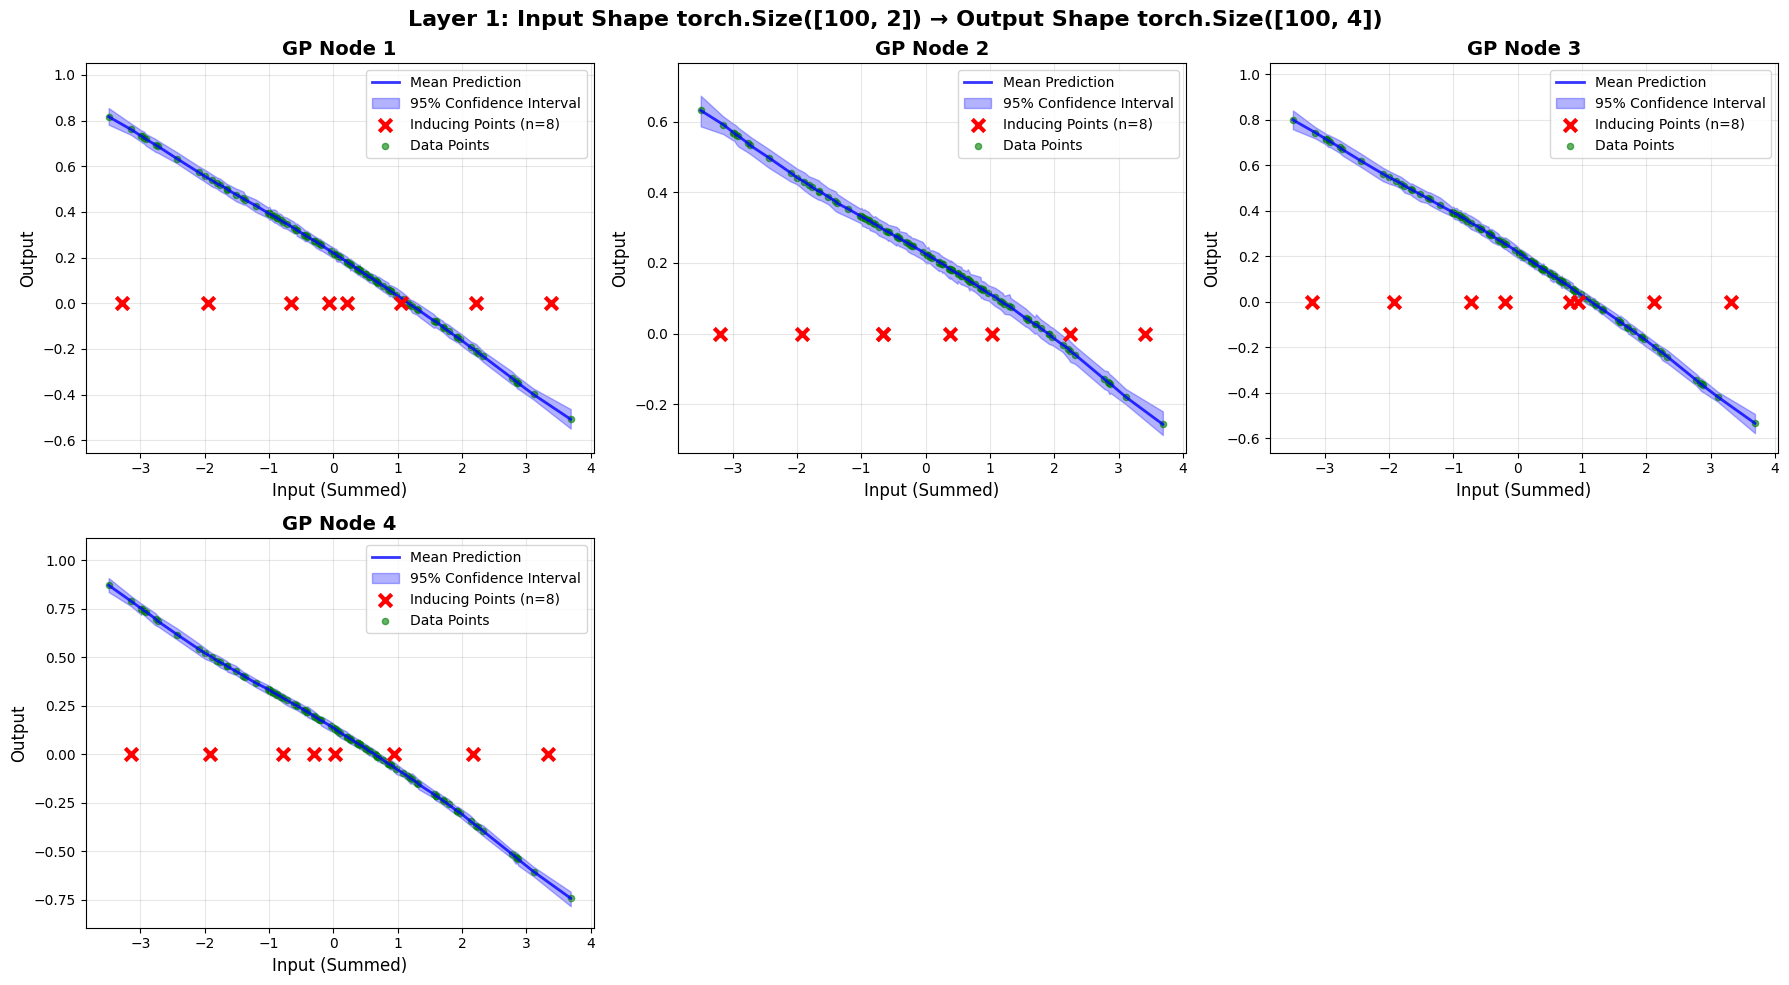

Visualizing GP-KAN layer behaviors...


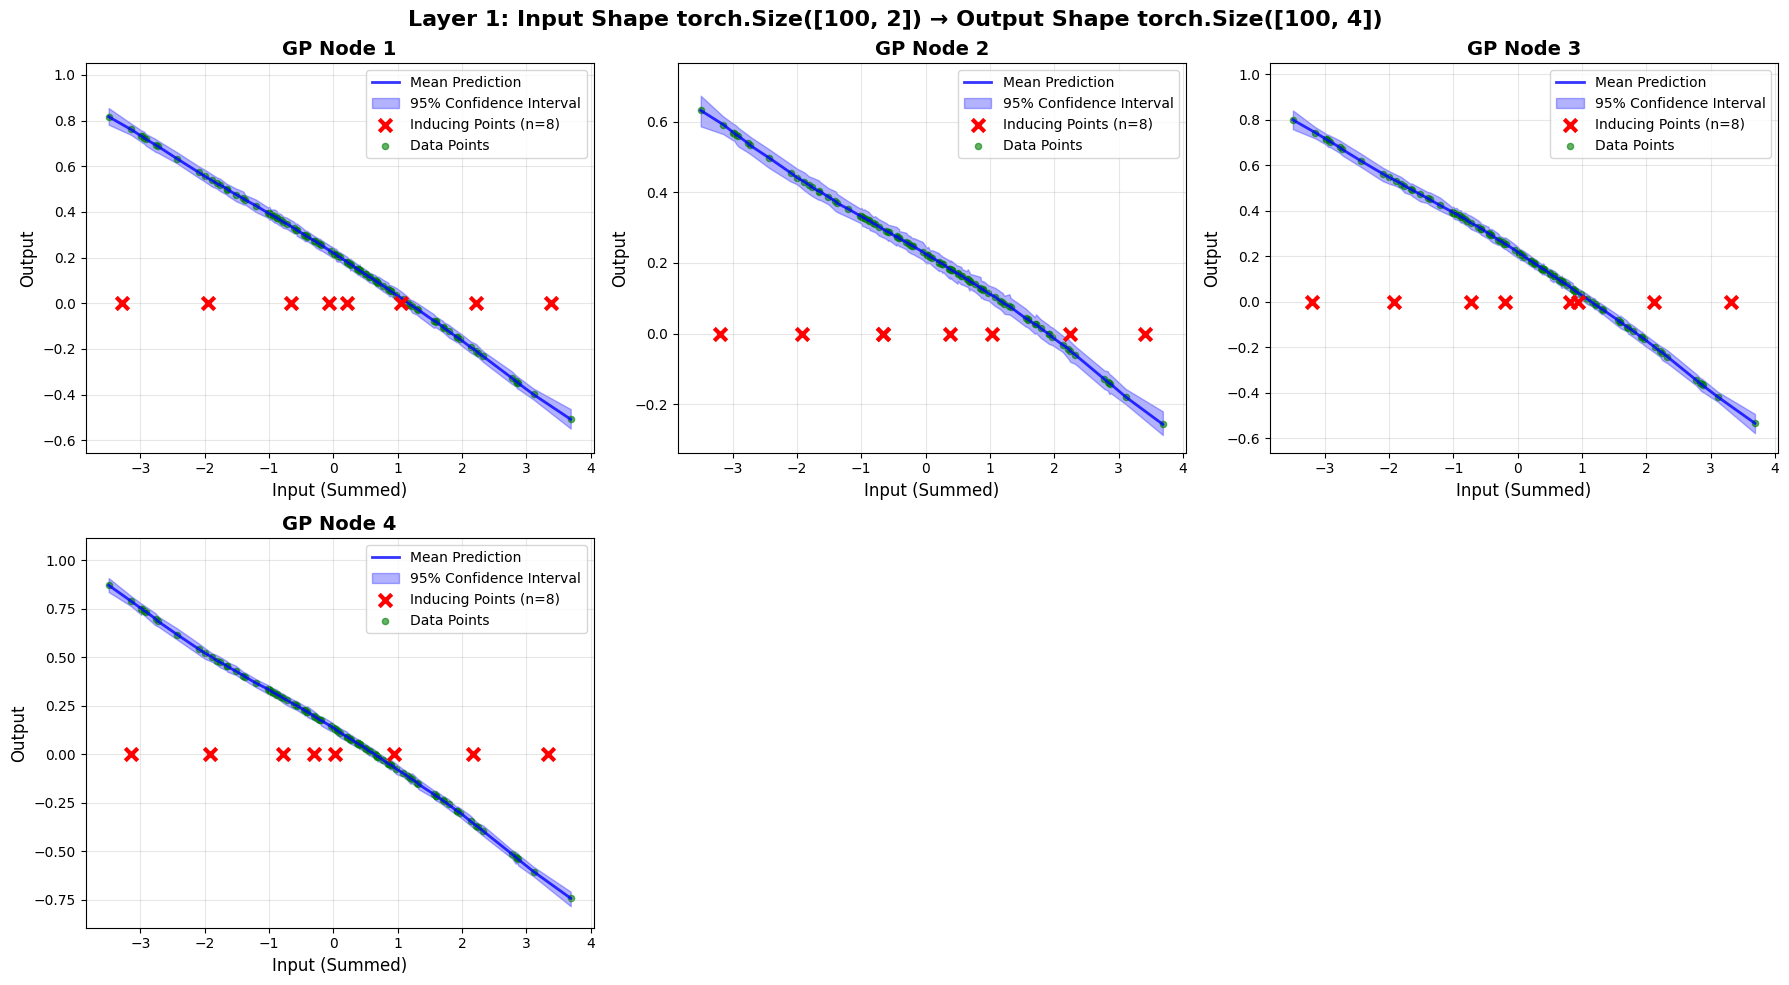

=== Layer 1 Statistics ===
Input shape: torch.Size([100, 2])
Output shape: torch.Size([100, 4])
Number of GP nodes: 4
  Node 1:
    Mean output: 0.1976
    Mean uncertainty: 0.0131
    Inducing points range: [-3.284, 3.384]
  Node 2:
    Mean output: 0.2136
    Mean uncertainty: 0.0130
    Inducing points range: [-3.196, 3.403]
  Node 3:
    Mean output: 0.1928
    Mean uncertainty: 0.0128
    Inducing points range: [-3.194, 3.311]
  Node 4:
    Mean output: 0.1093
    Mean uncertainty: 0.0126
    Inducing points range: [-3.144, 3.332]



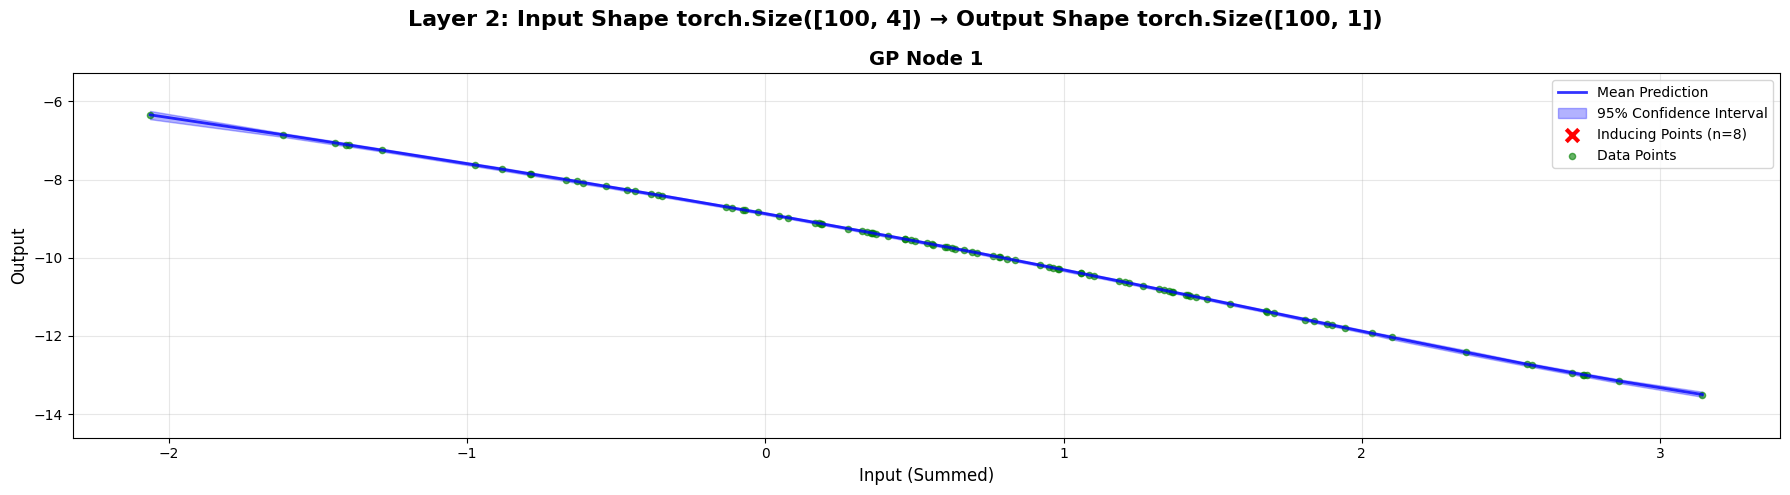

=== Layer 2 Statistics ===
Input shape: torch.Size([100, 4])
Output shape: torch.Size([100, 1])
Number of GP nodes: 1
  Node 1:
    Mean output: -9.9436
    Mean uncertainty: 0.0180
    Inducing points range: [-1.942, 2.980]



In [24]:
# 各層の可視化を実行
print("Visualizing GP-KAN layer behaviors...")

visualize_gpkan_layers(
    layer_analysis=layer_analysis,
    input_range=(-4, 4),
    figsize=(18, 10)
)

Visualizing inducing points evolution...


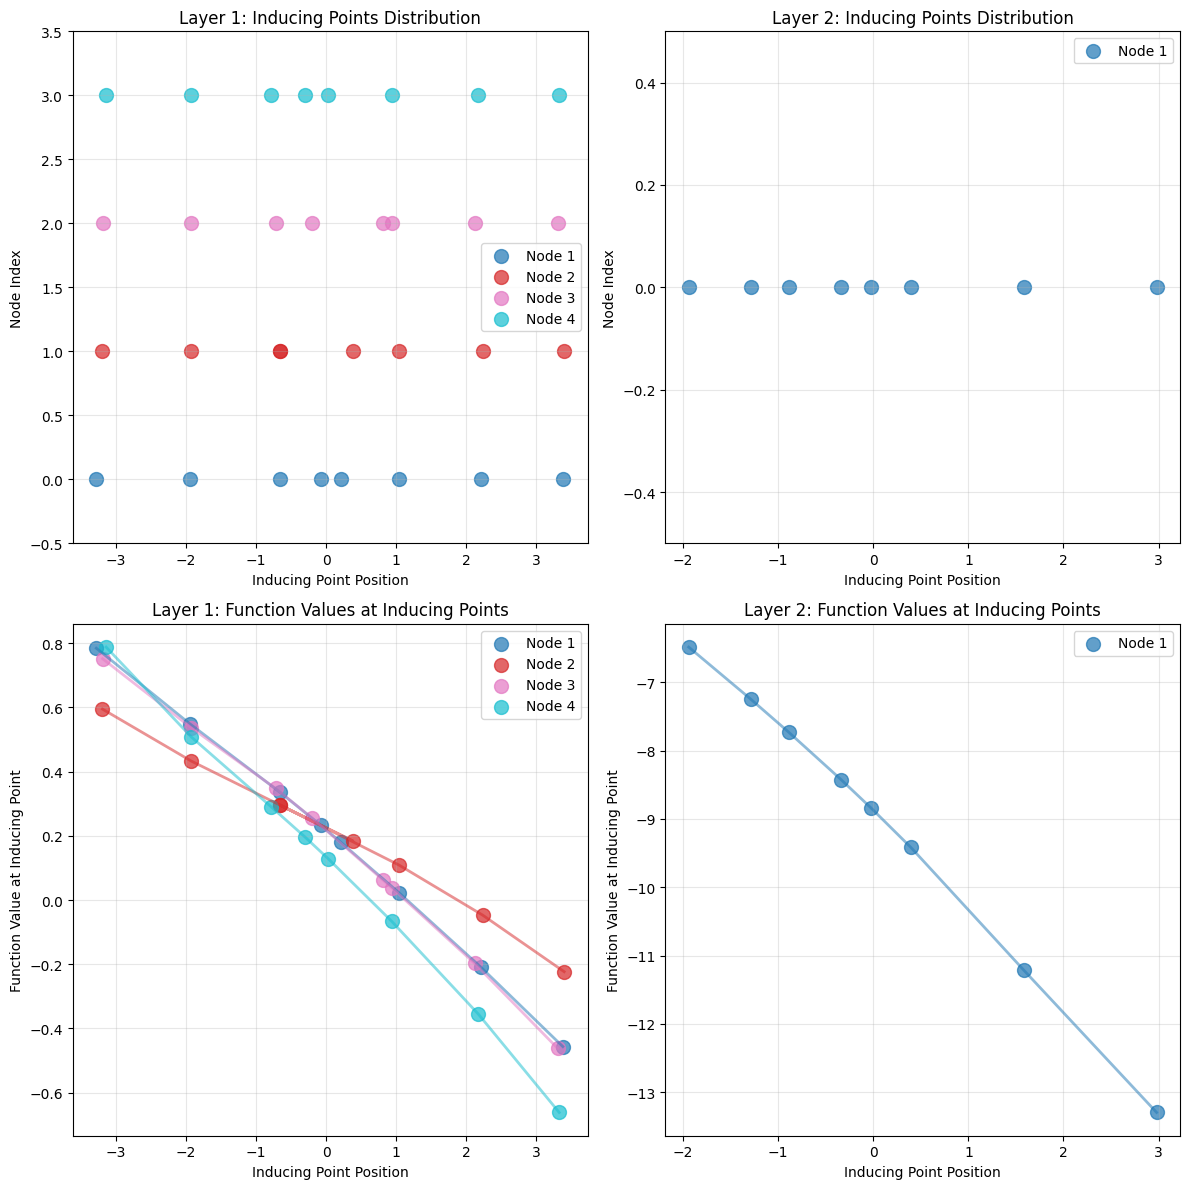

=== Inducing Points Statistics ===

Layer 1:
  Node 1: 8 points
    Range: [-3.284, 3.384]
    Mean: 0.111, Std: 2.012
  Node 2: 8 points
    Range: [-3.196, 3.403]
    Mean: 0.078, Std: 2.018
  Node 3: 8 points
    Range: [-3.194, 3.311]
    Mean: 0.143, Std: 1.979
  Node 4: 8 points
    Range: [-3.144, 3.332]
    Mean: 0.039, Std: 1.968
  Layer total: 32 inducing points
  Overall range: [-3.284, 3.403]

Layer 2:
  Node 1: 8 points
    Range: [-1.942, 2.980]
    Mean: 0.060, Std: 1.494
  Layer total: 8 inducing points
  Overall range: [-1.942, 2.980]


In [27]:
def visualize_inducing_points_evolution(layer_analysis):
    """
    各層の誘導点の配置と学習された値の進化を可視化
    """
    num_layers = len(layer_analysis)
    
    fig, axes = plt.subplots(2, num_layers, figsize=(6 * num_layers, 12))
    
    if num_layers == 1:
        axes = axes.reshape(-1, 1)
    
    for layer_idx, layer_info in enumerate(layer_analysis):
        num_nodes = len(layer_info['gp_nodes'])
        
        # 上段: 誘導点の分布
        ax_top = axes[0, layer_idx]
        
        all_inducing_points = []
        node_colors = plt.cm.tab10(np.linspace(0, 1, num_nodes))
        
        for node_idx, node_info in enumerate(layer_info['gp_nodes']):
            inducing_pts = node_info['inducing_points'].flatten()
            all_inducing_points.extend(inducing_pts)
            
            ax_top.scatter(inducing_pts, 
                          [node_idx] * len(inducing_pts),
                          color=node_colors[node_idx], 
                          s=100, alpha=0.7,
                          label=f'Node {node_idx + 1}')
        
        ax_top.set_xlabel('Inducing Point Position')
        ax_top.set_ylabel('Node Index')
        ax_top.set_title(f'Layer {layer_idx + 1}: Inducing Points Distribution')
        ax_top.legend()
        ax_top.grid(True, alpha=0.3)
        ax_top.set_ylim(-0.5, num_nodes - 0.5)
        
        # 下段: 誘導点でのGP関数値の予測
        ax_bottom = axes[1, layer_idx]
        
        for node_idx, node_info in enumerate(layer_info['gp_nodes']):
            inducing_pts = node_info['inducing_points'].flatten()
            
            # 誘導点での予測を計算
            inducing_tensor = torch.FloatTensor(inducing_pts).reshape(-1, 1)
            
            # GP分布を使って誘導点での予測値を取得
            with torch.no_grad():
                # 誘導点での関数値を推定（誘導点自体を入力として使用）
                inducing_tensor = torch.FloatTensor(inducing_pts).reshape(-1, 1)
                
                # 該当するGPノードを取得
                layer = improved_gpkan.layers[layer_idx]
                gp_node = layer.gp_nodes[node_idx]
                
                # 誘導点での予測を実行
                gp_output = gp_node(inducing_tensor)
                inducing_values = gp_output.mean.detach().numpy().flatten()
            
            ax_bottom.scatter(inducing_pts, inducing_values,
                            color=node_colors[node_idx], 
                            s=100, alpha=0.7,
                            label=f'Node {node_idx + 1}')
            
            ax_bottom.plot(inducing_pts, inducing_values,
                         color=node_colors[node_idx], 
                         alpha=0.5, linewidth=2)
        
        ax_bottom.set_xlabel('Inducing Point Position')
        ax_bottom.set_ylabel('Function Value at Inducing Point')
        ax_bottom.set_title(f'Layer {layer_idx + 1}: Function Values at Inducing Points')
        ax_bottom.legend()
        ax_bottom.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 誘導点の統計情報
    print("=== Inducing Points Statistics ===")
    for layer_idx, layer_info in enumerate(layer_analysis):
        print(f"\nLayer {layer_idx + 1}:")
        
        all_inducing = []
        for node_idx, node_info in enumerate(layer_info['gp_nodes']):
            inducing_pts = node_info['inducing_points'].flatten()
            all_inducing.extend(inducing_pts)
            
            print(f"  Node {node_idx + 1}: {len(inducing_pts)} points")
            print(f"    Range: [{inducing_pts.min():.3f}, {inducing_pts.max():.3f}]")
            print(f"    Mean: {inducing_pts.mean():.3f}, Std: {inducing_pts.std():.3f}")
        
        all_inducing = np.array(all_inducing)
        print(f"  Layer total: {len(all_inducing)} inducing points")
        print(f"  Overall range: [{all_inducing.min():.3f}, {all_inducing.max():.3f}]")

# 誘導点の進化を可視化
print("Visualizing inducing points evolution...")
visualize_inducing_points_evolution(layer_analysis)

In [26]:
def create_layer_summary_table(layer_analysis):
    """
    各層の特性をまとめた表を作成
    """
    import pandas as pd
    
    summary_data = []
    
    for layer_idx, layer_info in enumerate(layer_analysis):
        num_nodes = len(layer_info['gp_nodes'])
        
        for node_idx, node_info in enumerate(layer_info['gp_nodes']):
            # 統計量の計算
            mean_output = np.mean(node_info['mean_prediction'])
            std_output = np.mean(node_info['std_prediction'])
            min_output = np.min(node_info['mean_prediction'])
            max_output = np.max(node_info['mean_prediction'])
            
            # 誘導点の情報
            inducing_pts = node_info['inducing_points'].flatten()
            num_inducing = len(inducing_pts)
            inducing_range = f"[{inducing_pts.min():.2f}, {inducing_pts.max():.2f}]"
            
            # 入力の情報
            input_vals = node_info['input_values'].flatten()
            input_range = f"[{input_vals.min():.2f}, {input_vals.max():.2f}]"
            
            summary_data.append({
                'Layer': f"Layer {layer_idx + 1}",
                'Node': f"Node {node_idx + 1}",
                'Input Range': input_range,
                'Output Mean': f"{mean_output:.4f}",
                'Output Std': f"{std_output:.4f}",
                'Output Range': f"[{min_output:.2f}, {max_output:.2f}]",
                'Num Inducing': num_inducing,
                'Inducing Range': inducing_range
            })
    
    df = pd.DataFrame(summary_data)
    
    print("=== GP-KAN Layer Summary ===")
    print(df.to_string(index=False))
    
    return df

# サマリー表の作成
summary_df = create_layer_summary_table(layer_analysis)

=== GP-KAN Layer Summary ===
  Layer   Node   Input Range Output Mean Output Std    Output Range  Num Inducing Inducing Range
Layer 1 Node 1 [-3.49, 3.69]      0.1976     0.0131   [-0.51, 0.82]             8  [-3.28, 3.38]
Layer 1 Node 2 [-3.49, 3.69]      0.2136     0.0130   [-0.26, 0.63]             8  [-3.20, 3.40]
Layer 1 Node 3 [-3.49, 3.69]      0.1928     0.0128   [-0.53, 0.80]             8  [-3.19, 3.31]
Layer 1 Node 4 [-3.49, 3.69]      0.1093     0.0126   [-0.74, 0.87]             8  [-3.14, 3.33]
Layer 2 Node 1 [-2.06, 3.14]     -9.9436     0.0180 [-13.50, -6.35]             8  [-1.94, 2.98]


### 3.6 1次元ガウス過程活性化関数の詳細分析

GP-KANの各ノードにおける1次元ガウス過程活性化関数を個別に分析し、その入出力特性と誘導点の詳細を確認します。

In [ ]:
def analyze_1d_gp_activation_functions(
    model: ImprovedGPKAN, 
    sample_data: torch.Tensor, 
    input_range=(-4, 4), 
    resolution=200
):
    """
    各層の1次元GP活性化関数を詳細に分析
    
    Args:
        model: 学習済みのImprovedGPKANモデル
        sample_data: 分析用の入力データ
        input_range: 活性化関数を評価する入力範囲
        resolution: 評価点の密度
    
    Returns:
        activation_analysis: 各1次元GP活性化関数の詳細情報
    """
    model.eval_mode()
    activation_analysis = []
    
    # 1次元入力範囲を作成（活性化関数の詳細評価用）
    x_dense = torch.linspace(input_range[0], input_range[1], resolution).reshape(-1, 1)
    
    # 実際のデータフローに基づく分析
    current_input = sample_data
    
    for layer_idx, layer in enumerate(model.layers):
        layer_activations = []
        
        for gp_idx, (gp_node, likelihood) in enumerate(zip(layer.gp_nodes, layer.likelihoods)):
            print(f"Analyzing Layer {layer_idx + 1}, 1D-GP Activation Function {gp_idx + 1}")
            
            # 実データでの入力（エッジでの総和後）
            if current_input.size(-1) > 1:
                summed_input = current_input.sum(dim=-1, keepdim=True)
            else:
                summed_input = current_input
            
            with torch.no_grad():
                # 1. 実データでのGP出力
                real_gp_output = gp_node(summed_input)
                real_mean = real_gp_output.mean.detach().numpy()
                real_var = real_gp_output.variance.detach().numpy()
                
                # 2. 密な1次元入力での活性化関数評価
                dense_gp_output = gp_node(x_dense)
                dense_mean = dense_gp_output.mean.detach().numpy()
                dense_var = dense_gp_output.variance.detach().numpy()
                
                # 3. 複数回サンプリング（関数の形状理解）
                function_samples = []
                for _ in range(50):
                    sample = gp_node(x_dense).rsample().detach().numpy()
                    function_samples.append(sample)
                function_samples = np.array(function_samples)
                
                # 4. 誘導点での詳細分析
                inducing_points = gp_node.get_inducing_points().detach()
                inducing_gp_output = gp_node(inducing_points)
                inducing_mean = inducing_gp_output.mean.detach().numpy()
                inducing_var = inducing_gp_output.variance.detach().numpy()
                
                # 5. 変分パラメータ
                var_dist = gp_node.variational_strategy.variational_distribution
                if hasattr(var_dist, 'variational_mean'):\n                    variational_mean = var_dist.variational_mean.detach().numpy()\n                else:\n                    variational_mean = None\n                \n                # 6. カーネルパラメータ\n                kernel_info = {}\n                for name, param in gp_node.covar_module.named_parameters():\n                    kernel_info[name] = param.detach().numpy()\n            \n            activation_info = {\n                'layer_idx': layer_idx,\n                'gp_idx': gp_idx,\n                'gp_id': f'L{layer_idx + 1}_GP{gp_idx + 1}',\n                \n                # 実データでの動作\n                'real_input': summed_input.detach().numpy(),\n                'real_output_mean': real_mean,\n                'real_output_var': real_var,\n                \n                # 密な評価での活性化関数\n                'dense_input': x_dense.detach().numpy().flatten(),\n                'dense_output_mean': dense_mean.flatten(),\n                'dense_output_var': dense_var.flatten(),\n                'function_samples': function_samples,\n                \n                # 誘導点での詳細\n                'inducing_points': inducing_points.detach().numpy().flatten(),\n                'inducing_output_mean': inducing_mean,\n                'inducing_output_var': inducing_var,\n                'variational_mean': variational_mean,\n                \n                # GP特性\n                'kernel_params': kernel_info,\n                'num_inducing': len(inducing_points),\n            }\n            \n            layer_activations.append(activation_info)\n        \n        activation_analysis.extend(layer_activations)\n        \n        # 次の層への入力を計算\n        if layer_idx < len(model.layers) - 1:  # 最終層でなければ\n            current_input = layer(current_input)\n    \n    return activation_analysis\n\nprint(\"1D GP activation analysis function defined successfully\")"

In [ ]:
def visualize_individual_1d_gp_functions(activation_analysis):
    """
    各1次元GP活性化関数を個別に詳細可視化
    """
    # 総GP数を計算
    total_gps = len(activation_analysis)
    
    # すべてのGPを一つの大きな図にプロット
    cols = 4  # 1行に4つのGP
    rows = (total_gps + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows))
    if rows == 1 and cols == 1:
        axes = [axes]
    elif rows == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    fig.suptitle('All 1D GP Activation Functions in GP-KAN', fontsize=18, fontweight='bold')
    
    for gp_idx, gp_info in enumerate(activation_analysis):\n        ax = axes[gp_idx]\n        \n        # 密な評価での活性化関数\n        x_vals = gp_info['dense_input']\n        mean_vals = gp_info['dense_output_mean']\n        var_vals = gp_info['dense_output_var']\n        std_vals = np.sqrt(var_vals)\n        \n        # サンプル関数を複数プロット（薄い線）\n        samples = gp_info['function_samples']\n        for i in range(min(10, len(samples))):\n            ax.plot(x_vals, samples[i], color='lightblue', alpha=0.3, linewidth=0.8)\n        \n        # GP平均と不確実性\n        ax.plot(x_vals, mean_vals, 'b-', linewidth=2.5, label='GP Mean', alpha=0.9)\n        ax.fill_between(x_vals, mean_vals - 2*std_vals, mean_vals + 2*std_vals,\n                       alpha=0.3, color='blue', label='±2σ')\n        \n        # 誘導点\n        inducing_pts = gp_info['inducing_points']\n        inducing_means = gp_info['inducing_output_mean']\n        ax.scatter(inducing_pts, inducing_means, \n                  color='red', s=80, marker='x', linewidth=2.5,\n                  label=f'Inducing Points (n={len(inducing_pts)})', zorder=5)\n        \n        # 実データでの入出力\n        real_input = gp_info['real_input'].flatten()\n        real_output = gp_info['real_output_mean'].flatten()\n        \n        # 実データ点をサンプリングして表示（多すぎる場合）\n        if len(real_input) > 50:\n            indices = np.random.choice(len(real_input), 50, replace=False)\n            real_input_sample = real_input[indices]\n            real_output_sample = real_output[indices]\n        else:\n            real_input_sample = real_input\n            real_output_sample = real_output\n            \n        ax.scatter(real_input_sample, real_output_sample, \n                  color='green', s=15, alpha=0.7, label='Real Data Points')\n        \n        # カーネルパラメータ情報\n        kernel_info = gp_info['kernel_params']\n        lengthscale = kernel_info.get('base_kernel.lengthscale', kernel_info.get('lengthscale', [1.0]))[0]\n        outputscale = kernel_info.get('outputscale', [1.0])[0]\n        \n        ax.set_title(\n            f\"{gp_info['gp_id']}\\n\"\n            f\"Input: R¹→R¹ | Inducing: {gp_info['num_inducing']}\\n\"\n            f\"ℓ={lengthscale:.3f}, σ²={outputscale:.3f}\",\n            fontsize=11, fontweight='bold'\n        )\n        ax.set_xlabel('Input (Scalar)', fontsize=10)\n        ax.set_ylabel('Output (Scalar)', fontsize=10)\n        ax.legend(fontsize=8)\n        ax.grid(True, alpha=0.3)\n    \n    # 未使用のサブプロットを非表示\n    for i in range(total_gps, len(axes)):\n        axes[i].set_visible(False)\n    \n    plt.tight_layout()\n    plt.show()\n    \n    # 各GP活性化関数の詳細情報を表示\n    print(\"\\n=== Individual 1D GP Activation Function Analysis ===\")\n    for gp_info in activation_analysis:\n        print(f\"\\n{gp_info['gp_id']}:\")\n        print(f\"  Function Type: 1D Gaussian Process (R¹ → R¹)\")\n        print(f\"  Inducing Points: {gp_info['num_inducing']} points\")\n        print(f\"  Inducing Range: [{gp_info['inducing_points'].min():.3f}, {gp_info['inducing_points'].max():.3f}]\")\n        \n        kernel_info = gp_info['kernel_params']\n        lengthscale = kernel_info.get('base_kernel.lengthscale', kernel_info.get('lengthscale', [1.0]))[0]\n        outputscale = kernel_info.get('outputscale', [1.0])[0]\n        print(f\"  Kernel: RBF with lengthscale={lengthscale:.4f}, outputscale={outputscale:.4f}\")\n        \n        # 実データでの統計\n        real_input_range = [gp_info['real_input'].min(), gp_info['real_input'].max()]\n        real_output_range = [gp_info['real_output_mean'].min(), gp_info['real_output_mean'].max()]\n        print(f\"  Real Input Range: [{real_input_range[0]:.3f}, {real_input_range[1]:.3f}]\")\n        print(f\"  Real Output Range: [{real_output_range[0]:.3f}, {real_output_range[1]:.3f}]\")\n        \n        # 変分パラメータ\n        if gp_info['variational_mean'] is not None:\n            var_mean_stats = gp_info['variational_mean']\n            print(f\"  Variational Mean: [{var_mean_stats.min():.3f}, {var_mean_stats.max():.3f}]\")\n\nprint(\"1D GP visualization function defined successfully\")"

In [ ]:
def create_1d_gp_comparison_table(activation_analysis):
    """
    各1次元GP活性化関数の特性を比較表で表示
    """
    import pandas as pd
    \n    summary_data = []\n    \n    for gp_info in activation_analysis:\n        # カーネルパラメータ\n        kernel_info = gp_info['kernel_params']\n        lengthscale = kernel_info.get('base_kernel.lengthscale', kernel_info.get('lengthscale', [1.0]))[0]\n        outputscale = kernel_info.get('outputscale', [1.0])[0]\n        \n        # 入出力統計\n        real_input_range = f\"[{gp_info['real_input'].min():.2f}, {gp_info['real_input'].max():.2f}]\"\n        real_output_range = f\"[{gp_info['real_output_mean'].min():.2f}, {gp_info['real_output_mean'].max():.2f}]\"\n        \n        # 誘導点統計\n        inducing_range = f\"[{gp_info['inducing_points'].min():.2f}, {gp_info['inducing_points'].max():.2f}]\"\n        \n        # 関数の複雑さ指標（出力の標準偏差）\n        output_complexity = np.std(gp_info['dense_output_mean'])\n        \n        # 不確実性の平均\n        avg_uncertainty = np.mean(np.sqrt(gp_info['real_output_var']))\n        \n        summary_data.append({\n            '1D-GP ID': gp_info['gp_id'],\n            'Function': 'R¹ → R¹',\n            'Lengthscale': f\"{lengthscale:.4f}\",\n            'Output Scale': f\"{outputscale:.4f}\",\n            'Num Inducing': gp_info['num_inducing'],\n            'Inducing Range': inducing_range,\n            'Real Input Range': real_input_range,\n            'Real Output Range': real_output_range,\n            'Function Complexity': f\"{output_complexity:.4f}\",\n            'Avg Uncertainty': f\"{avg_uncertainty:.4f}\"\n        })\n    \n    df = pd.DataFrame(summary_data)\n    \n    print(\"=== 1D GP Activation Functions Comparison Table ===\")\n    print(df.to_string(index=False))\n    \n    # 統計サマリー\n    print(f\"\\n=== Summary Statistics ===\")\n    print(f\"Total 1D GP Activation Functions: {len(activation_analysis)}\")\n    \n    lengthscales = [float(row['Lengthscale']) for row in summary_data]\n    outputscales = [float(row['Output Scale']) for row in summary_data]\n    complexities = [float(row['Function Complexity']) for row in summary_data]\n    \n    print(f\"Lengthscale Range: [{min(lengthscales):.4f}, {max(lengthscales):.4f}]\")\n    print(f\"Output Scale Range: [{min(outputscales):.4f}, {max(outputscales):.4f}]\")\n    print(f\"Function Complexity Range: [{min(complexities):.4f}, {max(complexities):.4f}]\")\n    \n    # 多様性分析\n    lengthscale_diversity = np.std(lengthscales)\n    outputscale_diversity = np.std(outputscales)\n    complexity_diversity = np.std(complexities)\n    \n    print(f\"\\nParameter Diversity:\")\n    print(f\"  Lengthscale Std: {lengthscale_diversity:.4f}\")\n    print(f\"  Output Scale Std: {outputscale_diversity:.4f}\")\n    print(f\"  Complexity Std: {complexity_diversity:.4f}\")\n    \n    return df\n\nprint(\"1D GP comparison table function defined successfully\")"

In [ ]:
# 1次元GP活性化関数の詳細分析を実行\nprint(\"Analyzing individual 1D GP activation functions...\")\n\n# サンプルデータでの分析\nsample_size = 100\nsample_indices = np.random.choice(len(X_test), sample_size, replace=False)\nsample_data = X_test[sample_indices]\n\nprint(f\"Sample data shape: {sample_data.shape}\")\nprint(f\"Analyzing {len(improved_gpkan.layers)} layers...\")\n\n# 1次元GP活性化関数の分析\nactivation_analysis = analyze_1d_gp_activation_functions(\n    model=improved_gpkan,\n    sample_data=sample_data,\n    input_range=(-3, 3),\n    resolution=200\n)\n\nprint(f\"\\nTotal 1D GP activation functions analyzed: {len(activation_analysis)}\")\nfor i, gp_info in enumerate(activation_analysis):\n    print(f\"  {gp_info['gp_id']}: {gp_info['num_inducing']} inducing points\")"

In [ ]:
# 各1次元GP活性化関数の個別可視化\nprint(\"\\nVisualizing individual 1D GP activation functions...\")\nvisualize_individual_1d_gp_functions(activation_analysis)

In [ ]:
# 1次元GP活性化関数の比較表を作成\nprint(\"\\nCreating comparison table for 1D GP activation functions...\")\ngp_comparison_df = create_1d_gp_comparison_table(activation_analysis)

### 3.7 GP-KANにおける1次元ガウス過程の詳細分析

GP-KANの核心的な特徴である「各ノードでの1次元ガウス過程による活性化関数」について詳しく分析します。

In [ ]:
def analyze_gp_node_independence(model: ImprovedGPKAN):
    """
    各GPノードの独立性と1次元ガウス過程の詳細を分析
    """
    print("=== GP-KAN Node Independence Analysis ===")
    print(f"Architecture: {model.layer_sizes}")
    print()
    
    for layer_idx, layer in enumerate(model.layers):
        print(f"Layer {layer_idx + 1}: {layer.input_size}D → {layer.output_size}D")
        print(f"Number of GP nodes: {len(layer.gp_nodes)}")
        print()
        
        for node_idx, gp_node in enumerate(layer.gp_nodes):
            print(f"  GP Node {node_idx + 1}:")
            
            # 誘導点の詳細
            inducing_points = gp_node.get_inducing_points()
            print(f"    Inducing points shape: {inducing_points.shape}")
            print(f"    Inducing points: {inducing_points.detach().numpy().flatten()}")
            
            # カーネルパラメータ
            print(f"    Kernel type: {type(gp_node.covar_module).__name__}")
            for name, param in gp_node.covar_module.named_parameters():
                print(f"    {name}: {param.detach().numpy()}")
            
            # 平均関数
            print(f"    Mean function: {type(gp_node.mean_module).__name__}")
            for name, param in gp_node.mean_module.named_parameters():
                print(f"    {name}: {param.detach().numpy()}")
            
            # 変分パラメータ
            var_dist = gp_node.variational_strategy.variational_distribution
            if hasattr(var_dist, 'variational_mean'):
                var_mean = var_dist.variational_mean
                print(f"    Variational mean: {var_mean.detach().numpy()}")
            
            print(f"    Input dimension: {gp_node.input_dim}")
            print(f"    Expected input: スカラー値 (各エッジからの総和)")
            print()
        
        print(f"  Key Point: 各GPノードは独立した1次元ガウス過程")
        print(f"  - 入力: {layer.input_size}次元ベクトルの総和 → 1次元スカラー")
        print(f"  - 各ノードが独自のカーネルパラメータと変分パラメータを持つ")
        print(f"  - 出力: {layer.output_size}個の独立した1次元ガウス過程の出力")
        print("=" * 60)

# GP-KANの独立性分析を実行
analyze_gp_node_independence(improved_gpkan)